# GSE44076: First Exploratory PCA

This notebook uses principal component analysis (PCA) to inspect broad sample-level structure in the GSE44076 series matrix. PCA is exploratory and unsupervised: group labels are added only after fitting for visualization.

No samples are removed, and no differential expression, gene ranking, biomarker selection, or biological inference is performed.

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.geo_loader import (  # noqa: E402
    align_expression_with_metadata,
    build_sample_metadata_table,
    convert_expression_to_numeric,
    load_geo_expression_table,
    prepare_sample_feature_matrix,
    read_geo_series_lines,
    select_top_variable_features,
    summarize_sample_distributions,
)

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "GSE44076_series_matrix.txt.gz"
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "sample_metadata.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TOP_N_PROBES = 5000
GROUP_MAP = {
    "Healthy colon mucosa cells": "healthy_mucosa",
    "Normal distant colon mucosa cells": "paired_normal_mucosa",
    "Primary colon adenocarcinoma cells": "tumor",
}
GROUP_ORDER = ["healthy_mucosa", "paired_normal_mucosa", "tumor"]
GROUP_COLORS = {
    "healthy_mucosa": "#2A9D8F",
    "paired_normal_mucosa": "#E9C46A",
    "tumor": "#C8553D",
}

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## Load and Align Data

The matrix is loaded from the local GEO file, aligned to sample metadata, and converted to numeric values. The observed value scale remains described as log2-like pending confirmation from the original processing documentation.

In [2]:
if not RAW_PATH.is_file():
    raise FileNotFoundError(
        "GSE44076 series matrix not found. Place the downloaded file at "
        f"{RAW_PATH}"
    )

expression = load_geo_expression_table(RAW_PATH)
if METADATA_PATH.is_file():
    sample_metadata = pd.read_csv(METADATA_PATH)
else:
    sample_metadata = build_sample_metadata_table(read_geo_series_lines(RAW_PATH))

if "group" not in sample_metadata:
    sample_metadata["group"] = sample_metadata["source_name"].map(GROUP_MAP)
if sample_metadata["group"].isna().any():
    raise ValueError("Some sample source names do not have a documented group label.")

expression, sample_metadata = align_expression_with_metadata(expression, sample_metadata)
expression = convert_expression_to_numeric(expression)

print(f"Aligned expression table: {expression.shape}")
print(f"Samples represented in metadata: {len(sample_metadata)}")
print(f"Missing numeric values: {int(expression.drop(columns='ID_REF').isna().sum().sum()):,}")

Aligned expression table: (49386, 247)
Samples represented in metadata: 246
Missing numeric values: 0


## Select Variable Probes for Visualization

The 5,000 probes with the largest variance across samples are retained to reduce low-information dimensions and make this first PCA more stable and tractable. This unsupervised filter does not use group labels and is only for visualization; it is not biomarker selection or evidence that these probes are biologically important.

In [3]:
selected_expression = select_top_variable_features(expression, top_n=TOP_N_PROBES)
sample_feature_matrix = prepare_sample_feature_matrix(selected_expression)

expected_order = sample_metadata["sample_accession"].tolist()
if sample_feature_matrix.index.tolist() != expected_order:
    raise ValueError("PCA matrix rows are not aligned to metadata order.")

print(f"Probes available before filtering: {len(expression):,}")
print(f"Probes retained for PCA: {len(selected_expression):,}")
print(f"PCA input matrix: {sample_feature_matrix.shape[0]} samples x {sample_feature_matrix.shape[1]} probes")

Probes available before filtering: 49,386
Probes retained for PCA: 5,000
PCA input matrix: 246 samples x 5000 probes


## Reproduce Descriptive Sample Flags

The previous median/IQR screen is reproduced only to mark samples on the PCA plot. Tukey-style fences flag unusual marginal distributions; all samples remain in PCA.

In [4]:
sample_summary = summarize_sample_distributions(expression)

def tukey_fences(values):
    lower_quartile, upper_quartile = values.quantile([0.25, 0.75])
    spread = upper_quartile - lower_quartile
    return lower_quartile - 1.5 * spread, upper_quartile + 1.5 * spread


median_lower, median_upper = tukey_fences(sample_summary["median"])
iqr_lower, iqr_upper = tukey_fences(sample_summary["iqr"])
sample_summary["descriptive_flag"] = (
    ~sample_summary["median"].between(median_lower, median_upper)
    | ~sample_summary["iqr"].between(iqr_lower, iqr_upper)
)
flagged_accessions = sample_summary.index[sample_summary["descriptive_flag"]].tolist()

print(f"Descriptively flagged samples retained in PCA: {len(flagged_accessions)}")
display(pd.Series(flagged_accessions, name="sample_accession").to_frame())

Descriptively flagged samples retained in PCA: 7


,sample_accession
0,GSM1077600
1,GSM1077623
2,GSM1077627
3,GSM1077695
4,GSM1077736
5,GSM1077741
6,GSM1077793


## Fit PCA

Scikit-learn centers each probe before decomposition. Unit-variance scaling is not applied because all retained features are measurements from the same expression matrix, and scaling would remove the variance differences used for the unsupervised filter.

In [5]:
pca = PCA(n_components=10)
scores = pca.fit_transform(sample_feature_matrix)

score_table = pd.DataFrame(
    scores,
    index=sample_feature_matrix.index,
    columns=[f"PC{component}" for component in range(1, 11)],
).join(sample_metadata.set_index("sample_accession")[["group", "title"]])
score_table["descriptive_flag"] = score_table.index.isin(flagged_accessions)

explained_variance = pd.Series(
    pca.explained_variance_ratio_,
    index=[f"PC{component}" for component in range(1, 11)],
    name="explained_variance_ratio",
)
display(explained_variance.to_frame())
print(f"PC1 variance explained: {explained_variance['PC1']:.1%}")
print(f"PC2 variance explained: {explained_variance['PC2']:.1%}")
print(f"PC1 + PC2: {explained_variance[['PC1', 'PC2']].sum():.1%}")

,explained_variance_ratio
PC1,0.406965
PC2,0.170734
PC3,0.035910
PC4,0.029590
PC5,0.019219
PC6,0.018617
PC7,0.015097
PC8,0.013433
PC9,0.012124
PC10,0.011474


PC1 variance explained: 40.7%
PC2 variance explained: 17.1%
PC1 + PC2: 57.8%


## PC1 and PC2 by Metadata Group

Colors show metadata groups after PCA fitting. Open black circles mark the seven samples from the earlier descriptive screen.

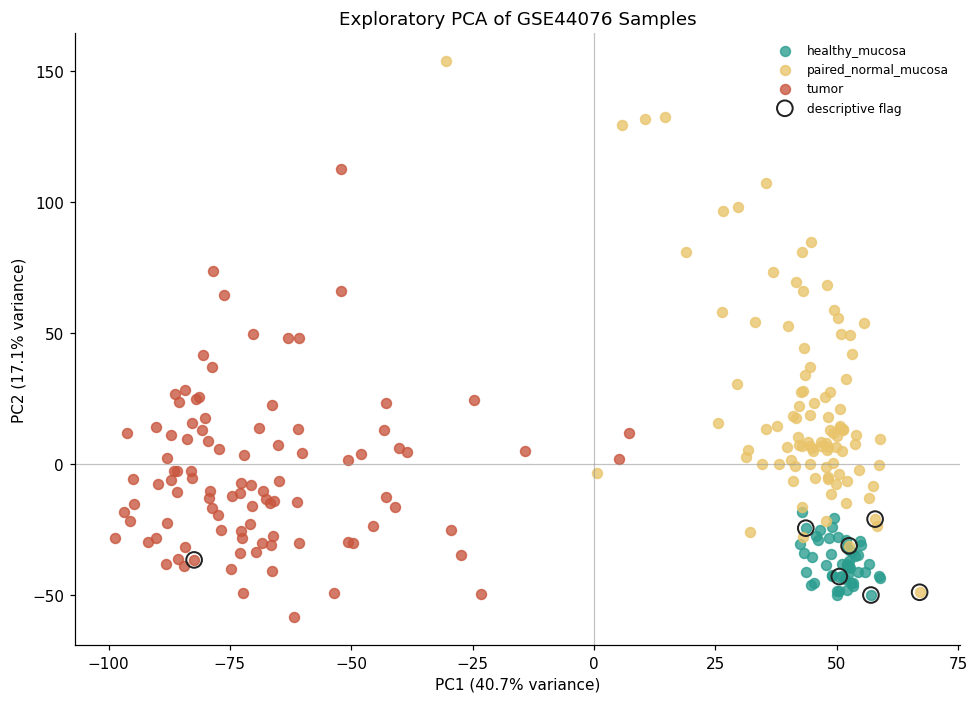

In [6]:
pc1_percent = explained_variance["PC1"] * 100
pc2_percent = explained_variance["PC2"] * 100

fig, ax = plt.subplots(figsize=(9, 6.5))
for group in GROUP_ORDER:
    group_scores = score_table[score_table["group"] == group]
    ax.scatter(
        group_scores["PC1"],
        group_scores["PC2"],
        s=42,
        alpha=0.78,
        color=GROUP_COLORS[group],
        label=group,
    )

flagged_scores = score_table[score_table["descriptive_flag"]]
ax.scatter(
    flagged_scores["PC1"],
    flagged_scores["PC2"],
    s=105,
    facecolors="none",
    edgecolors="#222222",
    linewidths=1.3,
    label="descriptive flag",
)
ax.axhline(0, color="#999999", linewidth=0.8, alpha=0.6)
ax.axvline(0, color="#999999", linewidth=0.8, alpha=0.6)
ax.set_title("Exploratory PCA of GSE44076 Samples")
ax.set_xlabel(f"PC1 ({pc1_percent:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pc2_percent:.1f}% variance)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pca_pc1_pc2_by_group.png", dpi=180, bbox_inches="tight")
plt.show()

## Explained Variance

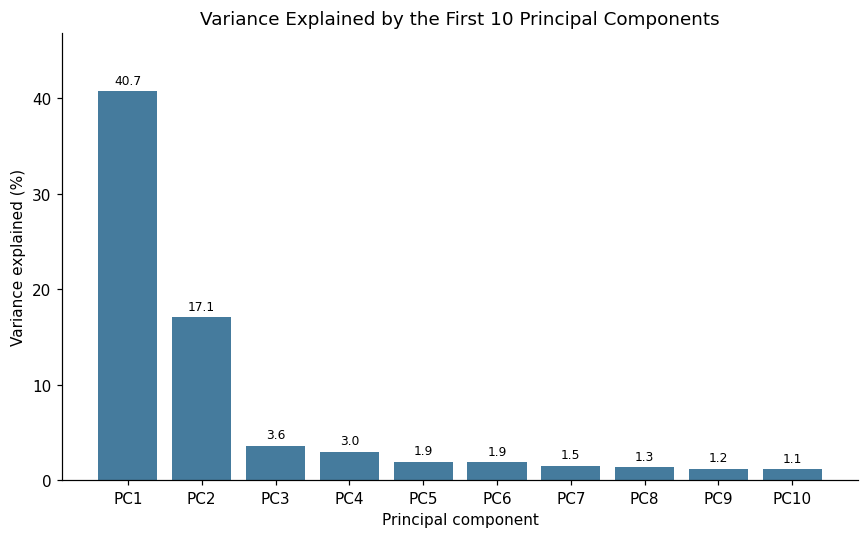

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(explained_variance.index, explained_variance.values * 100, color="#457B9D")
ax.bar_label(bars, labels=[f"{value * 100:.1f}" for value in explained_variance], padding=3, fontsize=8)
ax.set_title("Variance Explained by the First 10 Principal Components")
ax.set_xlabel("Principal component")
ax.set_ylabel("Variance explained (%)")
ax.set_ylim(0, explained_variance.max() * 115)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pca_explained_variance.png", dpi=180, bbox_inches="tight")
plt.show()

## What This PCA Can and Cannot Show

The first two components show visible sample structure associated with the recorded groups, with some within-group spread and overlap. This is a descriptive pattern in a variance-filtered projection, not evidence of a biological mechanism, diagnostic distinction, or validated subgroup.

PCA can help identify broad structure, possible technical effects, and samples that merit closer review. It cannot determine causality, establish differential expression, validate labels, or replace checks of platform annotation, preprocessing, batch variables, and the paired study design. The flagged samples should remain under review rather than being excluded from later work automatically.